<a href="https://colab.research.google.com/github/23f3001753-sys/Analysis-of-mobiledata-/blob/main/BDM_Capstone_Analysis_23F3001753.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyzing Sales Trends, Revenue Decline and Customer Payment Behaviour
### Multi-Channel Mobile Retail Business — BDM Capstone Project (Secondary Data)
**Name:** Aman Chawla  **Roll No:** 23F3001753

This notebook performs the complete data cleaning, descriptive statistics, and analysis
(monthly revenue trend, payment-channel contribution, and customer demographic segmentation)
for the "Mobile Sales Dataset" (Kaggle), supporting the objectives in the project report.



## 1. Load Data

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'/content/mobile_sales (1).csv')
df.head()


,TransactionID,Date,MobileModel,Brand,Price,UnitsSold,TotalRevenue,CustomerAge,CustomerGender,Location,PaymentMethod
0,79397f68-61ed-4ea8-bcb2-f918d4e6c05b,2024-01-06,direction,Green Inc,1196.95,85,28002.80,32,Female,Port Erik,Online
1,4f87d114-f522-4ead-93e3-f336402df6aa,2024-04-05,right,Thomas-Thompson,1010.34,64,2378.82,55,Female,East Linda,Credit Card
2,6750b7d6-dcc5-48c5-a76a-b6fc9d540fe1,2024-02-13,summer,Sanchez-Williams,400.80,95,31322.56,57,Male,East Angelicastad,Online
3,7da7de95-f772-4cc2-bce0-b0873f98233e,2024-04-17,keep,Greer and Sons,338.60,79,31159.75,46,Other,East Kevin,Cash
4,469044af-0d60-4d87-af66-c6603e844057,2024-06-02,option,Brown and Sons,839.79,41,11523.36,38,Male,New Lindaborough,Online


In [ ]:
print("shape:",df.shape)

shape: (1000, 11)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   TransactionID   1000 non-null   object 
 1   Date            1000 non-null   object 
 2   MobileModel     1000 non-null   object 
 3   Brand           1000 non-null   object 
 4   Price           1000 non-null   float64
 5   UnitsSold       1000 non-null   int64  
 6   TotalRevenue    1000 non-null   float64
 7   CustomerAge     1000 non-null   int64  
 8   CustomerGender  1000 non-null   object 
 9   Location        1000 non-null   object 
 10  PaymentMethod   1000 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 86.1+ KB


## 2. Metadata

| Column | Description |
|---|---|
| TransactionID | Unique identifier for each transaction |
| Date | Date of transaction (Jan–Jul 2024) |
| MobileModel | Model name/tag of device (synthetic placeholder text — see data-quality note) |
| Brand | Brand name (synthetic placeholder text — see data-quality note) |
| Price | Unit price of the device (₹) |
| UnitsSold | Number of units sold in the transaction |
| TotalRevenue | Revenue recorded for the transaction (₹) |
| CustomerAge | Age of the customer (years) |
| CustomerGender | Gender of the customer (Male/Female/Other) |
| Location | Customer's city (synthetic placeholder text) |
| PaymentMethod | Payment channel: Online, Credit Card, Debit Card, Cash |


## 3. Data Cleaning & Validation

In [ ]:
df.isnull().sum()

,0
TransactionID,0
Date,0
MobileModel,0
Brand,0
Price,0
UnitsSold,0
TotalRevenue,0
CustomerAge,0
CustomerGender,0
Location,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

print("price range:", df['Price'].min(),"-",df['Price'].max())
print("unit sold range:", df['UnitsSold'].min(),"-",df['UnitsSold'].max())
print("customer age range:", df['CustomerAge'].min(),"-",df['CustomerAge'].max())
print("date range:", df['Date'].min(),"-",df['Date'].max())


price range: 103.32 - 1499.25
unit sold range: 1 - 99
customer age range: 18 - 64
date range: 2024-01-01 00:00:00 - 2024-07-25 00:00:00


In [ ]:
# A key validation check is whether the recorded
# TotalRevenue equals Price*UnitsSold.

df['CalculatedRevenue'] = df['Price']*df['UnitsSold']
df['diff'] = (df['TotalRevenue']-df['CalculatedRevenue']).abs()
print(df['diff'])
print("1. mean difference:", df['diff'].mean())
print("2. rows where TotalRevenue == Price*UnitsSold:", (df['diff']<1).sum(), "out of", len(df))


0      73737.95
1      62282.94
2       6753.44
3       4410.35
4      22908.03
         ...   
995    76522.74
996    17924.92
997    30732.47
998    19329.00
999     6203.87
Name: diff, Length: 1000, dtype: float64
1. mean difference: 35130.139299999995
2. rows where TotalRevenue == Price*UnitsSold: 0 out of 1000


**Observation:** `TotalRevenue` does **not** equal `Price × UnitsSold` for virtually any row. This indicates the
`TotalRevenue` field was generated independently of `Price` and `UnitsSold`.
-> For this reason, the
analysis below treats **`TotalRevenue` as the
authoritative revenue figure** (as it would be in a real transactional system, e.g. reflecting discounts/taxes not
captured by other columns) and does not attempt to reconcile it with `Price × UnitsSold`.
-> Similarly, `MobileModel`,
`Brand`, and `Location` contain randomly generated placeholder text (e.g. brand names like "Green Inc", model names
like "direction") rather than real-world values, so brand/model/location-level analysis is not performed; the
analysis instead focuses on the fields with genuine business meaning: Date, Price, UnitsSold, TotalRevenue,
CustomerAge, CustomerGender, and PaymentMethod.

In [ ]:
for col in ['Price','UnitsSold','TotalRevenue','CustomerAge']:
  q1, q3 = df[col].quantile([0.25, 0.75])
  iqr = q3-q1
  lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
  n_out = df[(df[col]<lo)|(df[col]>hi)].shape[0]
  print(f"{col}: {n_out} outliers (bounds: {lo:.1f} to {hi:.1f})")



Price: 0 outliers (bounds: -591.7 to 2207.6)
UnitsSold: 0 outliers (bounds: -50.0 to 150.0)
TotalRevenue: 6 outliers (bounds: -57865.6 to 131952.0)
CustomerAge: 0 outliers (bounds: -7.0 to 89.0)


## 4. Descriptive Statistics

TotalRevenue comes out around 0.89 (moderately right-skewed — a longer tail of high-value transactions), which lines up with what the outlier check just showed.

In [ ]:
desc = df[['Price','UnitsSold','TotalRevenue','CustomerAge']].describe().T
desc['skew'] = df[['Price','UnitsSold','TotalRevenue','CustomerAge']].skew()
desc

,count,mean,std,min,25%,50%,75%,max,skew
Price,1000.0,807.51297,402.489878,103.32,458.0375,823.730,1157.875,1499.25,-0.023667
UnitsSold,1000.0,50.07400,28.616804,1.00,25.0000,51.000,75.000,99.00,-0.023209
TotalRevenue,1000.0,40218.44504,32715.290358,116.85,13316.0375,30860.655,60770.435,141411.84,0.892283
CustomerAge,1000.0,41.14100,13.528346,18.00,29.0000,41.000,53.000,64.00,0.005613


In [ ]:
print(df['PaymentMethod'].value_counts())
print(df['CustomerGender'].value_counts())

PaymentMethod
Credit Card    278
Online         259
Debit Card     246
Cash           217
Name: count, dtype: int64
CustomerGender
Female    341
Other     339
Male      320
Name: count, dtype: int64


## 5. Objective 1 — Monthly Sales & Revenue Trend Analysis

In [ ]:
monthly = df.groupby('Month').agg(
    Revenue = ('TotalRevenue','sum'),
    Units = ('UnitsSold','sum'),
    Transactions = ('TransactionID','count'),
    AvgPrice = ('Price','mean')
).reset_index()
monthly['Revenue_Lakh'] = monthly['Revenue']/1e5
monthly

,Month,Revenue,Units,Transactions,AvgPrice,Revenue_Lakh
0,1,6255585.41,7818,159,870.704088,62.555854
1,2,5920997.18,6729,144,807.782708,59.209972
2,3,5946336.12,7380,142,757.332042,59.463361
3,4,5423932.09,7697,139,777.187410,54.239321
4,5,5658005.29,7268,142,836.025775,56.580053
5,6,5963010.33,6809,146,794.799315,59.630103
6,7,5050578.62,6373,128,800.185547,50.505786


In [ ]:
pct_change = (monthly['Revenue'].iloc[-1]-monthly['Revenue'].iloc[0])/monthly['Revenue'].iloc[0]*100
print(f"revenue change jan->jul 2024: {pct_change:.2f}%")
# july has fewer calender days of data then other months
print("last transaction data in dataset:", df['Date'].max())
print("transaction per month:")
print(df['Month'].value_counts().sort_index())


revenue change jan->jul 2024: -19.26%
last transaction data in dataset: 2024-07-25 00:00:00
transaction per month:
Month
1    159
2    144
3    142
4    139
5    142
6    146
7    128
Name: count, dtype: int64


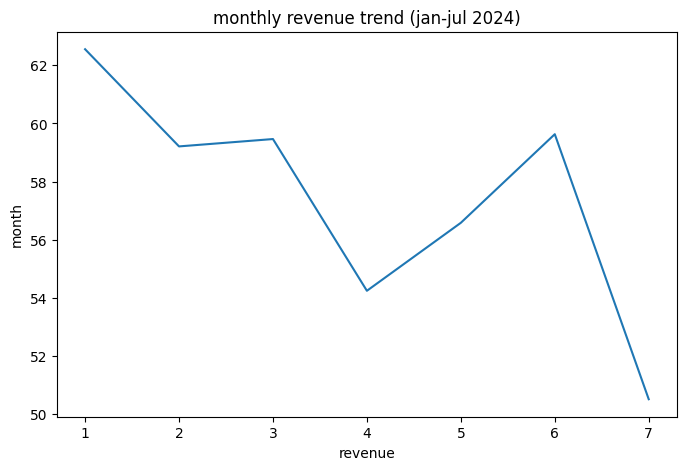

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(monthly['Month'], monthly['Revenue_Lakh'])

plt.title("monthly revenue trend (jan-jul 2024)")
plt.xlabel("revenue")
plt.ylabel("month")

plt.show()

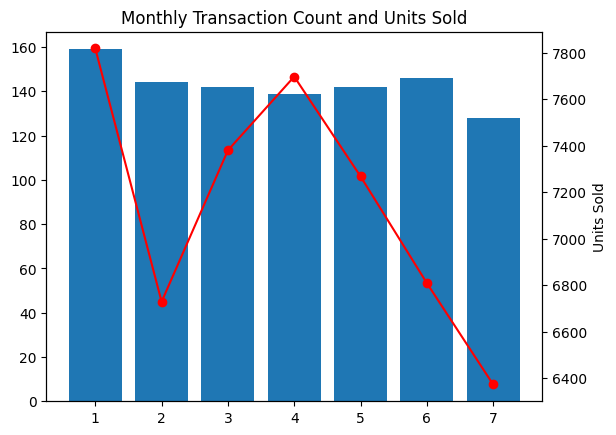

In [ ]:
# bar chart
plt.bar(monthly['Month'], monthly['Transactions'], label='Transactions')
ax2 = plt.twinx()

# Line chart
ax2.plot(monthly['Month'], monthly['Units'], color='red', marker='o', label='Units Sold')
plt.xlabel('Month')
plt.ylabel('Transactions')
ax2.set_ylabel('Units Sold')
plt.title('Monthly Transaction Count and Units Sold')
plt.show()

## 7. Objective 2a — Payment Channel Contribution Analysis

In [ ]:
channel = df.groupby('PaymentMethod').agg(
    Revenue = ('TotalRevenue','sum'),
    Units = ('UnitsSold','sum'),
    Transactions =('TransactionID','count'),
    AvgRevenuePerTxn = ('TotalRevenue','mean')
).reset_index()
channel['RevenueShare%'] = channel['Revenue']/channel['Revenue'].sum()*100
channel['TxnShare%'] = channel['Transactions']/channel['Transactions'].sum()*100
channel.sort_values('Revenue',ascending=False)

,PaymentMethod,Revenue,Units,Transactions,AvgRevenuePerTxn,RevenueShare%,TxnShare%
1,Credit Card,11298245.48,13826,278,40641.170791,28.092199,27.8
3,Online,10277204.48,12943,259,39680.326178,25.553461,25.9
2,Debit Card,9952877.90,12648,246,40458.853252,24.747048,24.6
0,Cash,8690117.18,10657,217,40046.622949,21.607293,21.7


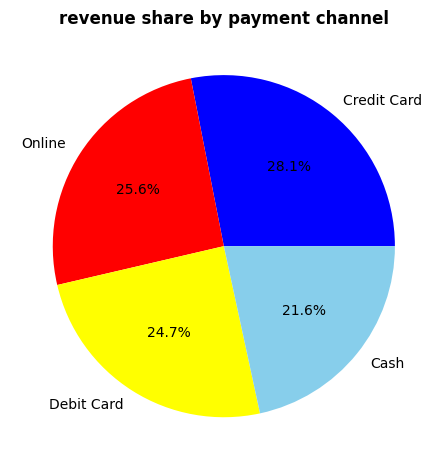

In [ ]:
ch = df.groupby('PaymentMethod')['TotalRevenue'].sum().sort_values(ascending=False)
plt.pie(ch.values, labels=ch.index, autopct='%1.1f%%', colors=['blue','red','yellow','skyblue'])
plt.title('revenue share by payment channel', fontweight ='bold')
plt.tight_layout()
plt.show()




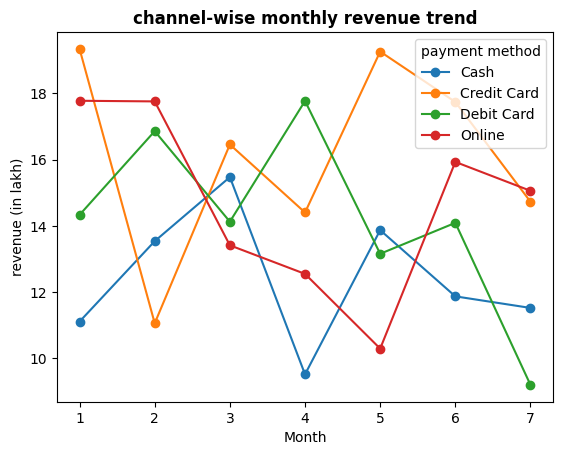

In [ ]:
channel_monthly = df.groupby(['Month','PaymentMethod'])['TotalRevenue'].sum().unstack()/1e5
for col in channel_monthly.columns:
  plt.plot(channel_monthly.index, channel_monthly[col], marker='o',label = col)
plt.title('channel-wise monthly revenue trend',fontweight='bold')
plt.ylabel('revenue (in lakh)'); plt.xlabel('Month'); plt.legend(title='payment method')
plt.show()

In [ ]:
print("% change jan-jul by channel: ")
print(((channel_monthly.iloc[-1]-channel_monthly.iloc[0])/channel_monthly.iloc[0]*100).round(2))

% change jan-jul by channel: 
PaymentMethod
Cash            3.71
Credit Card   -23.85
Debit Card    -35.82
Online        -15.29
dtype: float64


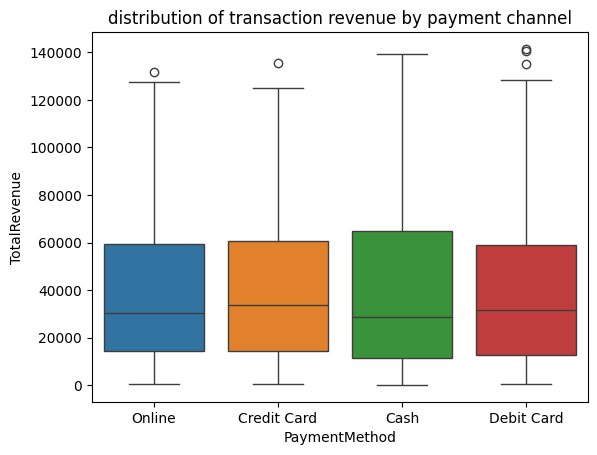

In [ ]:
import seaborn as sns
sns.boxplot(data=df, x='PaymentMethod', y='TotalRevenue', hue='PaymentMethod')
plt.title('distribution of transaction revenue by payment channel')
plt.show()

## 8. Objective 2b — Customer Demographic Segmentation

In [ ]:
bins = [17,27,37,47,57,66]
labels = ['18-27', '28-37', '38-47', '48-57', '58-65']
df['AgeGroup'] = pd.cut(df['CustomerAge'], bins=bins, labels=labels)

age_seg = df.groupby('AgeGroup', observed = True).agg(
    Revenue =('TotalRevenue','sum'), Transactions=('TransactionID', 'count'),
)

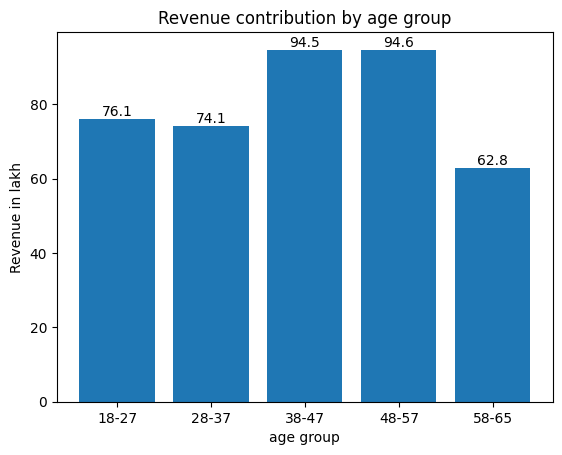

In [ ]:
vals = df.groupby('AgeGroup', observed=True)['TotalRevenue'].sum()/1e5
bars = plt.bar(vals.index.astype(str), vals.values)
plt.bar_label(bars, fmt='%.1f')
plt.title('Revenue contribution by age group')
plt.ylabel('Revenue in lakh'); plt.xlabel('age group')
plt.show()


In [ ]:
gender_seg = df.groupby('CustomerGender').agg(
    Revenue=('TotalRevenue','sum'), Transactions=('TransactionID','count'), AvgSpend=('TotalRevenue','mean')
).reset_index()
gender_seg['RevenueShare%'] = gender_seg['Revenue']/gender_seg['Revenue'].sum()*100
gender_seg

,CustomerGender,Revenue,Transactions,AvgSpend,RevenueShare%
0,Female,13471008.27,341,39504.423079,33.494602
1,Male,13279716.91,320,41499.115344,33.018972
2,Other,13467719.86,339,39727.787198,33.486426


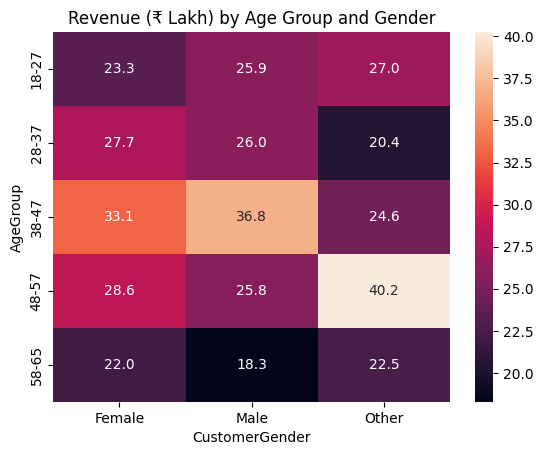

In [ ]:
piv = df.pivot_table(index='AgeGroup', columns='CustomerGender', values='TotalRevenue', aggfunc='sum', observed=True)/1e5
sns.heatmap(piv, fmt='.1f', annot=True)
plt.title('Revenue (₹ Lakh) by Age Group and Gender')
plt.show()


## 9. Correlation Analysis

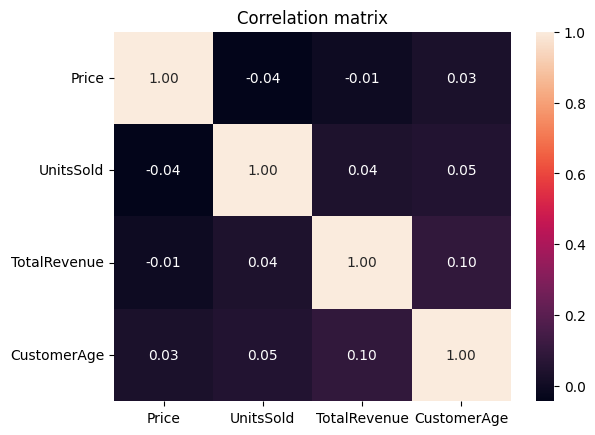

In [ ]:
corr = df[['Price','UnitsSold','TotalRevenue','CustomerAge']].corr()
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title('Correlation matrix')
plt.show()

## Observation:
All pairwise correlations between Price, UnitsSold, TotalRevenue and CustomerAge are close to zero (<0.10 in magnitude), indicating no meaningful linear relationshop between  these variables in this dataset - consistent with TotalRevenue being genrates insepedently os the other numeric fields.

## 10. Summary of Key Findings

1. Total revenue declined from ₹62.6 lakh (Jan 2024) to ₹50.5 lakh (Jul 2024), a fall of ~19.3%; however July's
   data covers only 25 days (partial month), so part of the apparent drop is a data-coverage artifact rather than a
   true trend — this should be corrected for before drawing firm conclusions.
2. All four payment channels contribute a broadly similar share of revenue (~22-28% each); Credit Card is the
   largest single channel by revenue share.
3. Debit Card revenue fell the most between January and July (-36%), while Cash was roughly flat/slightly up (~+4%) over the same window.
4. The 38-47 and 48-57 age groups contribute the largest share of revenue (23.5% each); 58-65 contributes the least(~15.6%).
5. Revenue contribution is nearly identical across the three gender categories (~33% each).
6. No meaningful correlation exists between price, units sold, revenue and customer age.

See the accompanying project report for the full interpretation and recommendations.